# AI 데이터센터 최적 입지 분석 v2
### 한국 AI 데이터센터 최적 입지 종합 분석

**v2 주요 업그레이드**
1. **AI DC 추출**: 188개 데이터센터 중 AI DC(Tier1/2) 66개 별도 분류
2. **위치 기반 신재생 접근성**: 풍력 116 단지 + 태양광 17,884 발전소 실좌표 활용
3. **송전 손실 보정**: 한국 계통 손실 3.8% + 거리 0.015%/km (154kV 기준)
4. **AHP 가중치**: Saaty 9점 쌍대비교 → CR=0.028 (일관성 검증 통과)
5. **AI DC 전력 수요 예측**: LLM API 사용량 통계 기반 2030년 예측
6. **시뮬레이션 v2**: 손실 보정 + 수도권 집중 vs. 최적 분산 시나리오


## 0. 환경 설정 및 데이터 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = '/Users/lshwa/Desktop/학술제/분석 진행'
VIZ  = BASE + '/시각화'
print('환경 설정 완료')

환경 설정 완료


## 1. AI 데이터센터 분류

Tier 분류 기준:
- **Tier1 AI특화**: NAVER, AWS, Kakao, NHN, KakaoCloud 운영
- **Tier2 하이퍼스케일**: LG CNS, KT IDC, SK, Microsoft, Google 등
- **Tier3 코로케이션**: 민간 코로케이션 사업자
- **Tier4 공공**: 행정기관, 공공기관

AI 학습/추론 워크로드 수행 가능한 Tier1+2를 분석 대상으로 선정


In [ ]:
ai_dc = pd.read_csv(BASE + '/AI_DC_분류결과.csv')
print(f'전체 DC: 188개 → AI DC(Tier1+2): {len(ai_dc)}개')
print(ai_dc['tier'].value_counts().to_string())
print(f"\n수도권 집중도: {ai_dc['수도권여부'].str.contains('수도권').sum() / len(ai_dc) * 100:.1f}%")

전체 DC: 188개 → AI DC(Tier1+2): 66개
tier
Tier2_하이퍼스케일    50
Tier1_AI특화         16

수도권 집중도: 70.4%


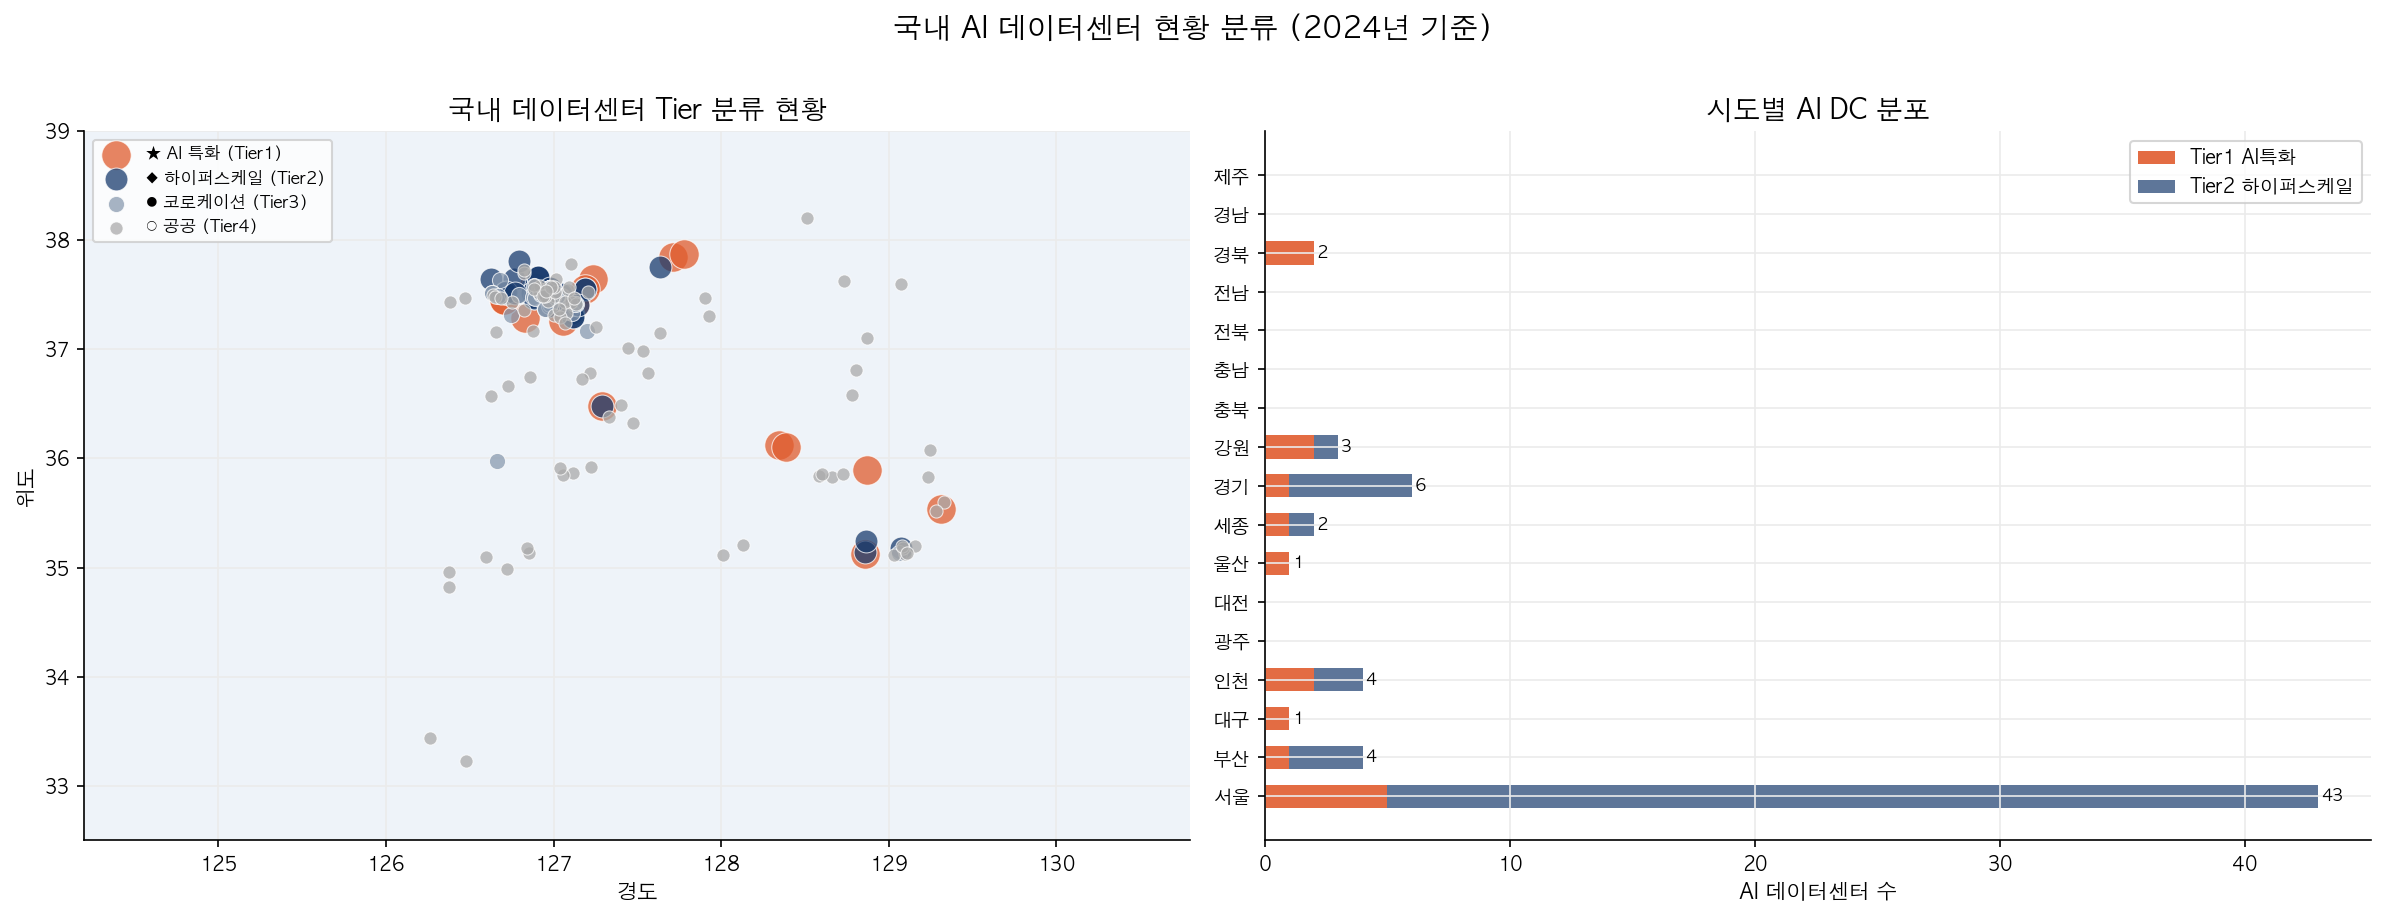

In [ ]:
from IPython.display import Image
Image(VIZ + '/00_AI_DC_현황분류.png')

## 2. AHP 기반 가중치 도출

Saaty(1980) 분석적계층과정(AHP) 적용 — 5개 기준 쌍대비교

| 기준 | AHP 가중치 |
|------|----------|
| 전력 접근성 | **49.7%** |
| 신재생에너지 접근성 | 24.5% |
| 냉각 여건 | 10.5% |
| 재해 안전 | 10.5% |
| 변전소 접근성 | 4.7% |

**일관성 비율(CR) = 0.028 < 0.1** → 가중치 신뢰도 검증 통과


In [ ]:
print('=== AHP 가중치 (DC 입지 선정 기준) ===
  전력접근성       : 0.4971  (49.7%)
  신재생에너지      : 0.2454  (24.5%)
  냉각여건        : 0.1053  (10.5%)
  재해안전        : 0.1053  (10.5%)
  변전소         : 0.0469  (4.7%)
λ_max=5.1274, CI=0.0318, CR=0.0284  ← 일관성 OK (CR<0.1)
')

=== AHP 가중치 (DC 입지 선정 기준) ===
  전력접근성       : 0.4971  (49.7%)
  신재생에너지      : 0.2454  (24.5%)
  냉각여건        : 0.1053  (10.5%)
  재해안전        : 0.1053  (10.5%)
  변전소         : 0.0469  (4.7%)
λ_max=5.1274, CI=0.0318, CR=0.0284  ← 일관성 OK (CR<0.1)


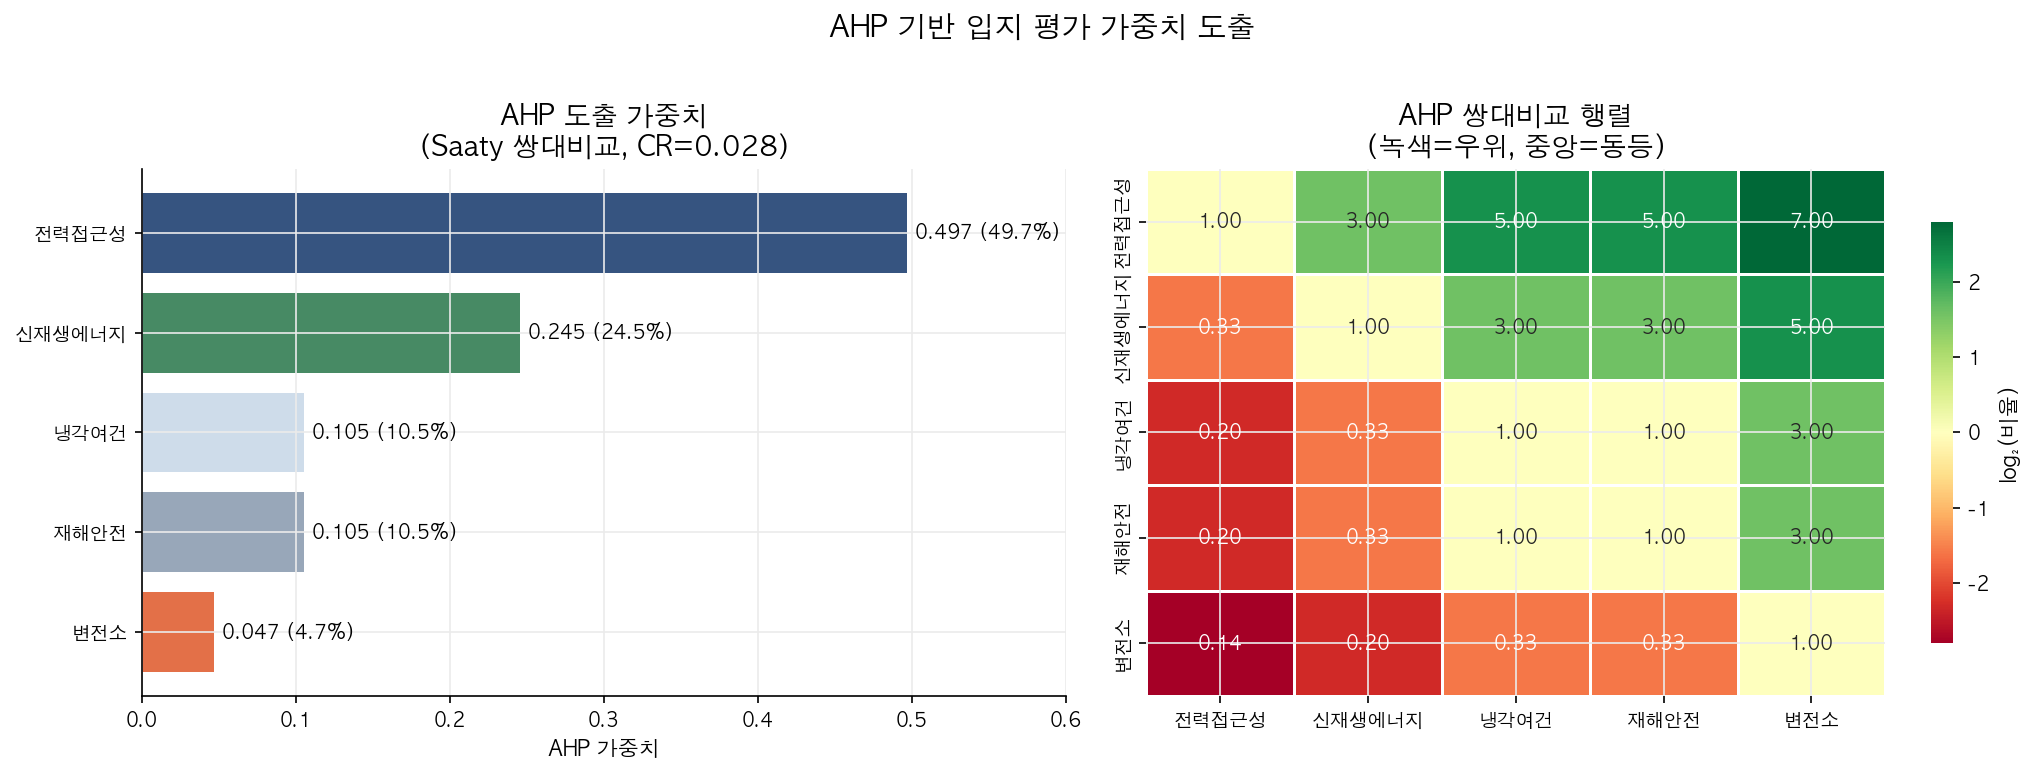

In [ ]:
Image(VIZ + '/09_AHP_가중치.png')

## 3. 위치 기반 신재생에너지 접근성 + 송전 손실 보정

### 3.1 데이터 소스
- **풍력**: 116개 단지, 780기 (2MW/기 가정) = 1,560 MW
- **태양광**: 17,884개 발전소 (한국에너지공단 실좌표)
- **핵심 발전소**: 100MW 이상 82개소, 116,937 MW

### 3.2 송전 손실 모델
```
손실률 = min(3.8% + 거리(km) × 0.015%, 25%)
유효 접근성 = Σ [ 용량(MW) × (1-손실률) / 거리(km)² ]
```
- 기준: 한국전력 154kV 계통 평균 손실 3.8%
- 거리 보정: 100km당 1.5% 추가 손실
- 최대 손실 상한: 25% (장거리 한계)


In [ ]:
# 송전 손실 모델 예시
import numpy as np

def transmission_loss_rate(dist_km):
    BASE_LOSS = 0.038
    DIST_LOSS_PER_KM = 0.00015
    return min(BASE_LOSS + dist_km * DIST_LOSS_PER_KM, 0.25)

dists = [0, 50, 100, 200, 300, 500]
print('거리(km) | 손실률(%)')
print('-' * 25)
for d in dists:
    print(f'  {d:5d}  |  {transmission_loss_rate(d)*100:.2f}%')

거리(km) | 손실률(%)
-------------------------
      0  |  3.80%
     50  |  4.55%
    100  |  5.30%
    200  |  6.80%
    300  |  8.30%
    500  | 11.30%


## 4. 시도 단위 입지 분석 (AHP 가중치 적용)

In [ ]:
sido = pd.read_csv(BASE + '/시도_입지점수.csv')
print(sido[['시도','수도권여부','전력자급률_%','신재생비율_%','연평균기온_C','AI_DC_수','점수_AHP_norm','순위_AHP']].to_string(index=False))

=== 시도 입지 점수 Top 5 (AHP 가중치, 송전 손실 보정) ===
  1위 울산    | 자급률  103.4% | AHP점수 1.000
  2위 인천    | 자급률  191.5% | AHP점수 0.921
  3위 세종    | 자급률  123.6% | AHP점수 0.914
  4위 부산    | 자급률  169.8% | AHP점수 0.657
  5위 광주    | 신재생   61.3% | AHP점수 0.587


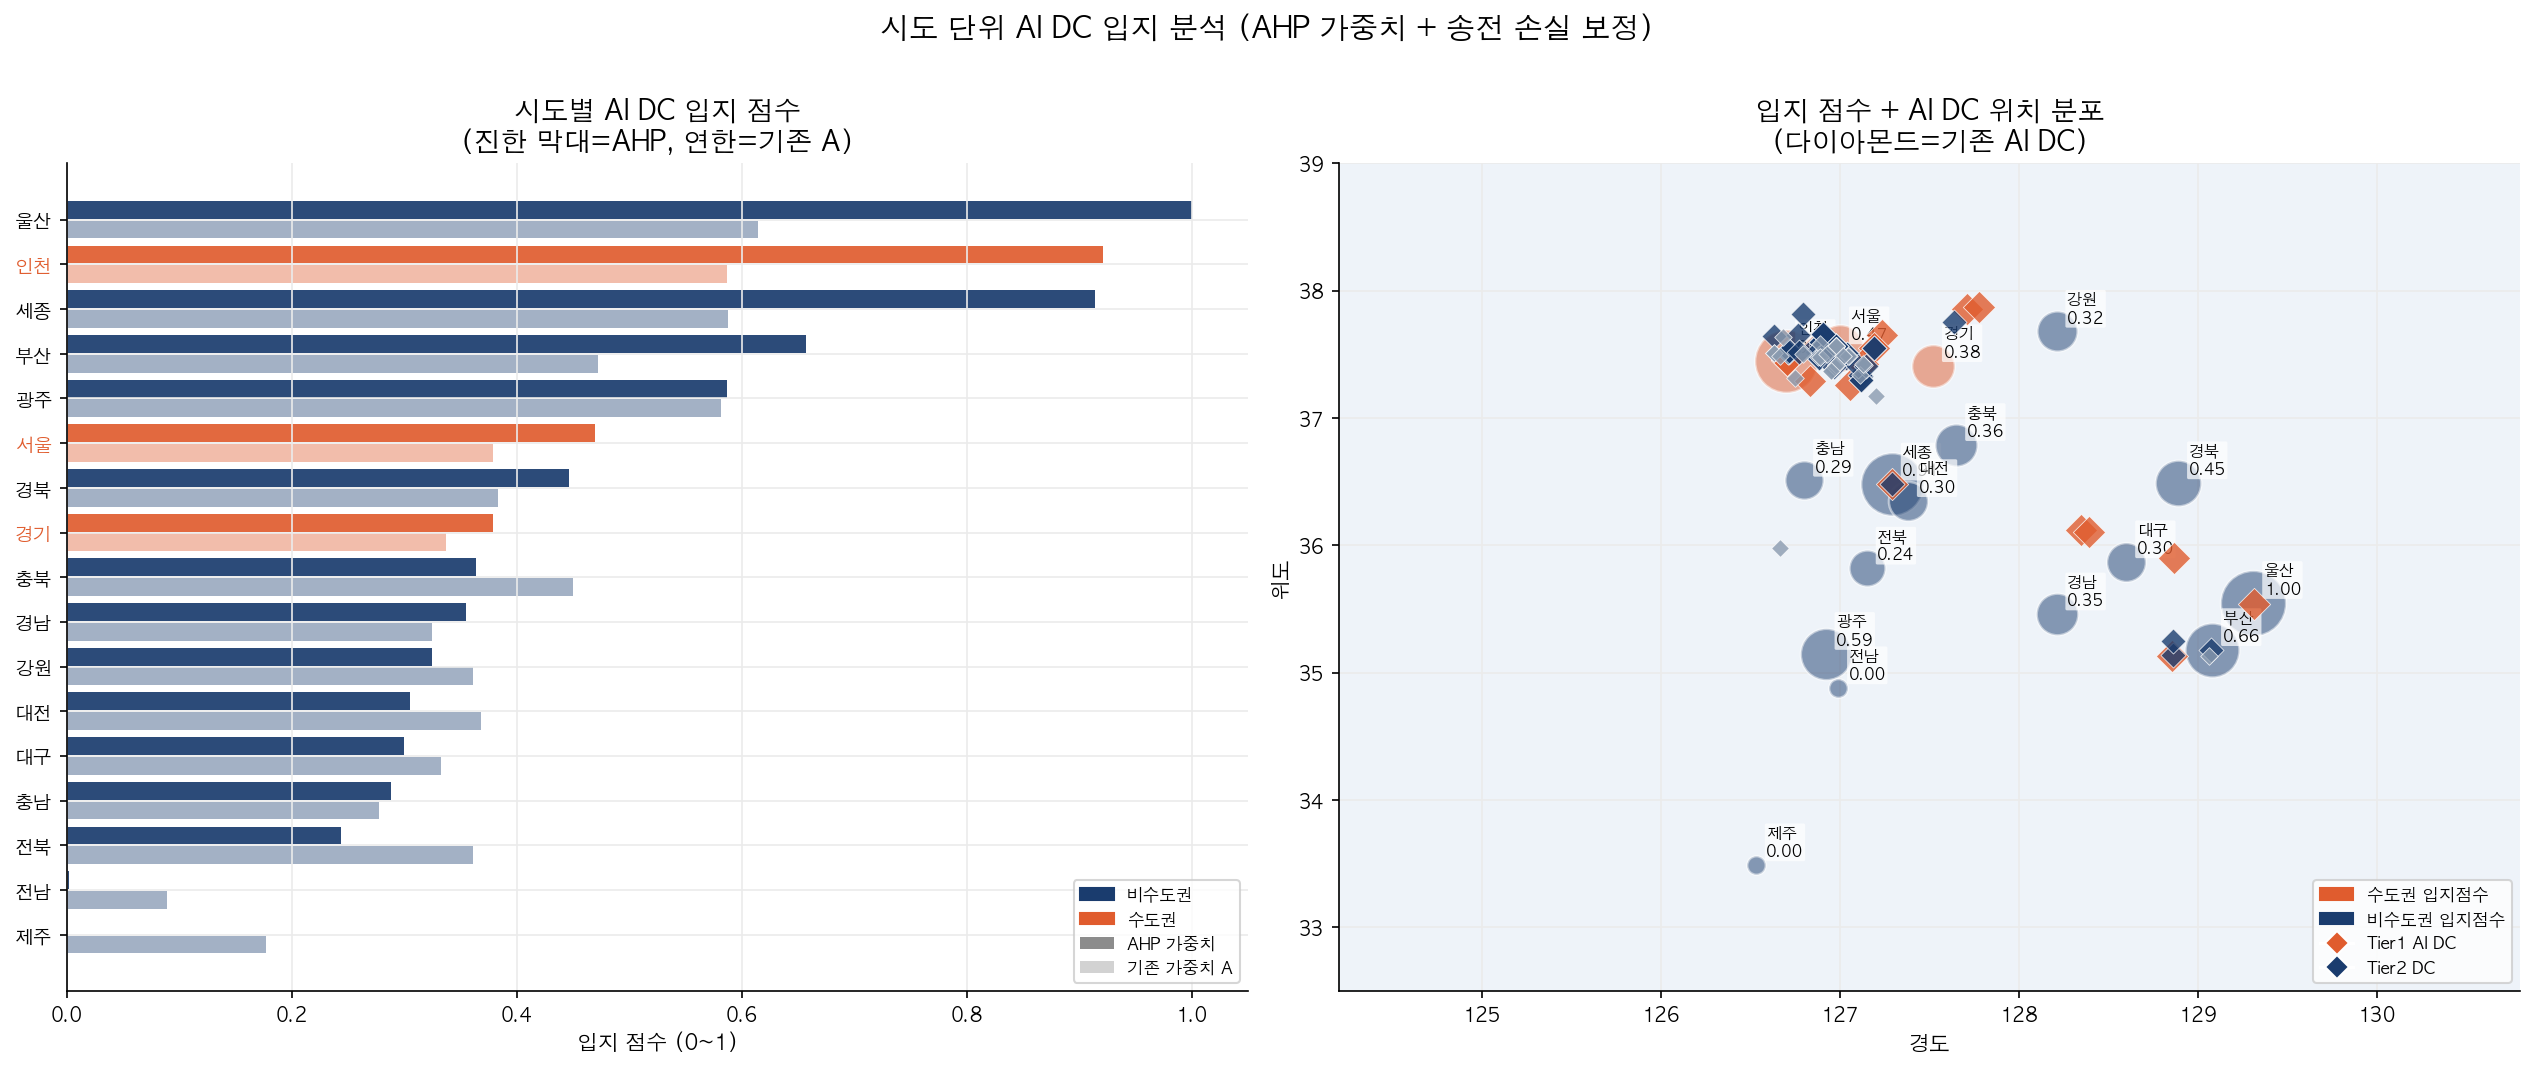

In [ ]:
Image(VIZ + '/01_시도_입지점수.png')

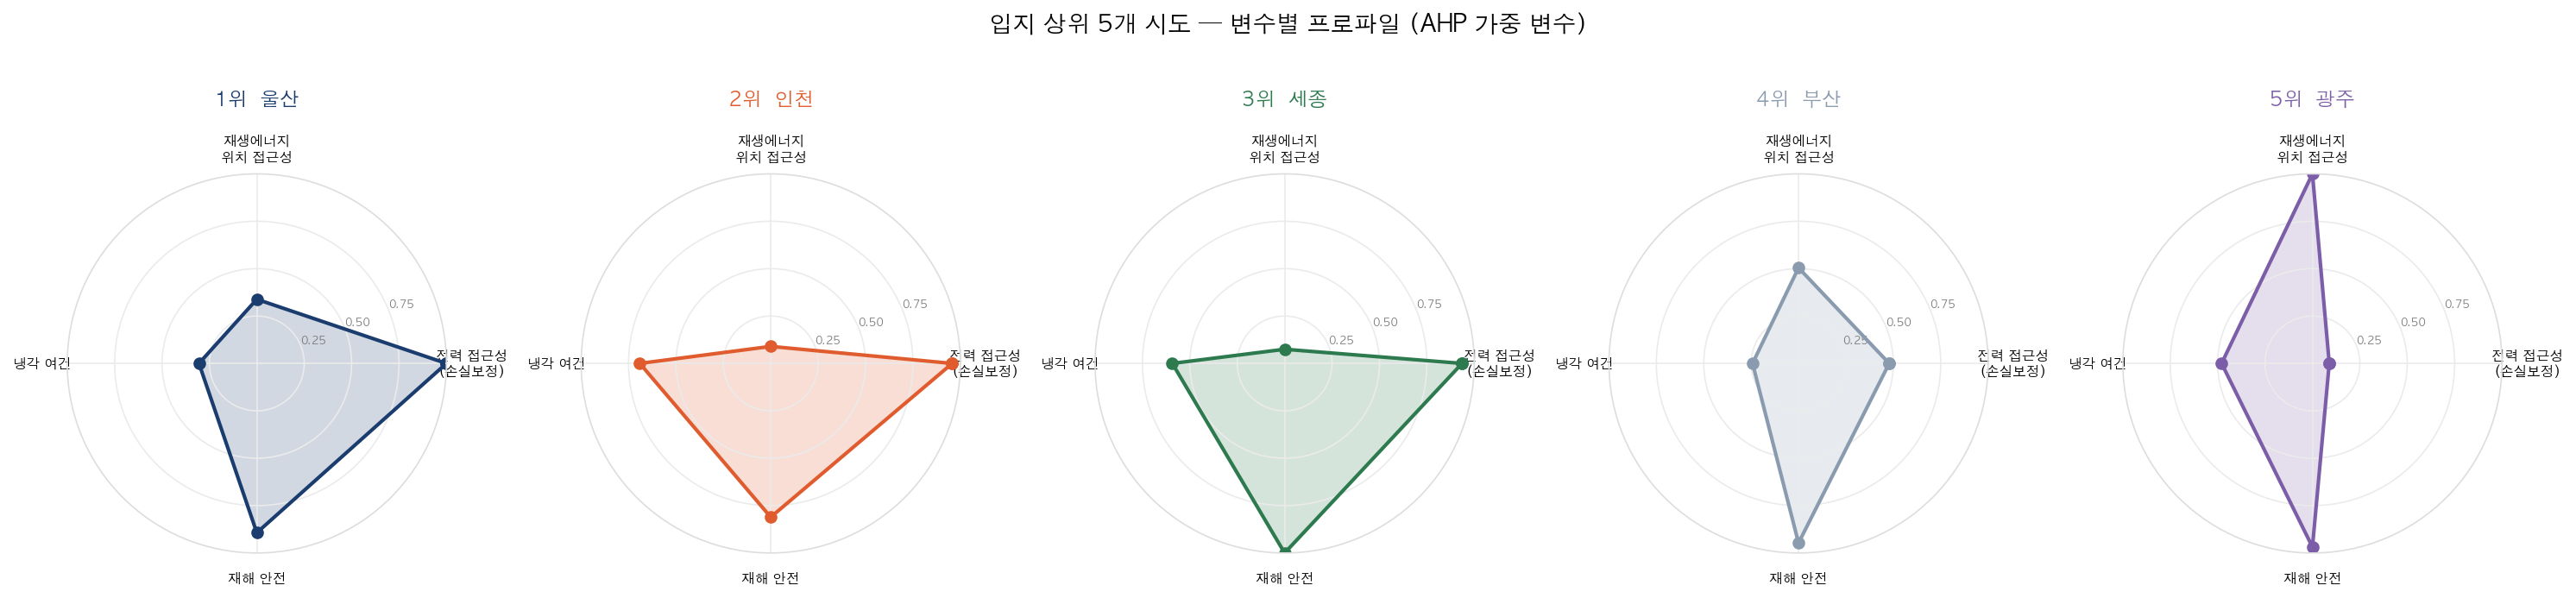

In [ ]:
Image(VIZ + '/02_시도_레이더차트.png')

## 5. 시군구 단위 입지 분석 (AHP + 송전 손실 보정)

시군구 가중치 (AHP 파생):
- 전력접근성(42%) + 신재생접근성(23%) + 냉각(13%) + 재해역(10%) + 신재생발전량(7%) + 변전소(5%)


In [ ]:
sg = pd.read_csv(BASE + '/시군구_입지점수.csv')
top10 = sg.nlargest(10, '입지점수')[['시도','시군구','입지점수','N_전력접근성','N_신재생접근성','N_냉각여건','N_재해역']]
top10.index = range(1, 11)
print(top10.to_string())

=== 시군구 입지 점수 Top 10 (AHP + 손실 보정) ===
   1위 경기    안양시동안구     | 0.569
   2위 울산    남구         | 0.488
   3위 부산    사하구        | 0.474
   4위 전북    무주군        | 0.440
   5위 경기    오산시        | 0.278
   6위 부산    서구         | 0.258
   7위 경북    청송군        | 0.252
   8위 경남    산청군        | 0.236
   9위 강원    평창군        | 0.234
  10위 경기    안산시단원구     | 0.233


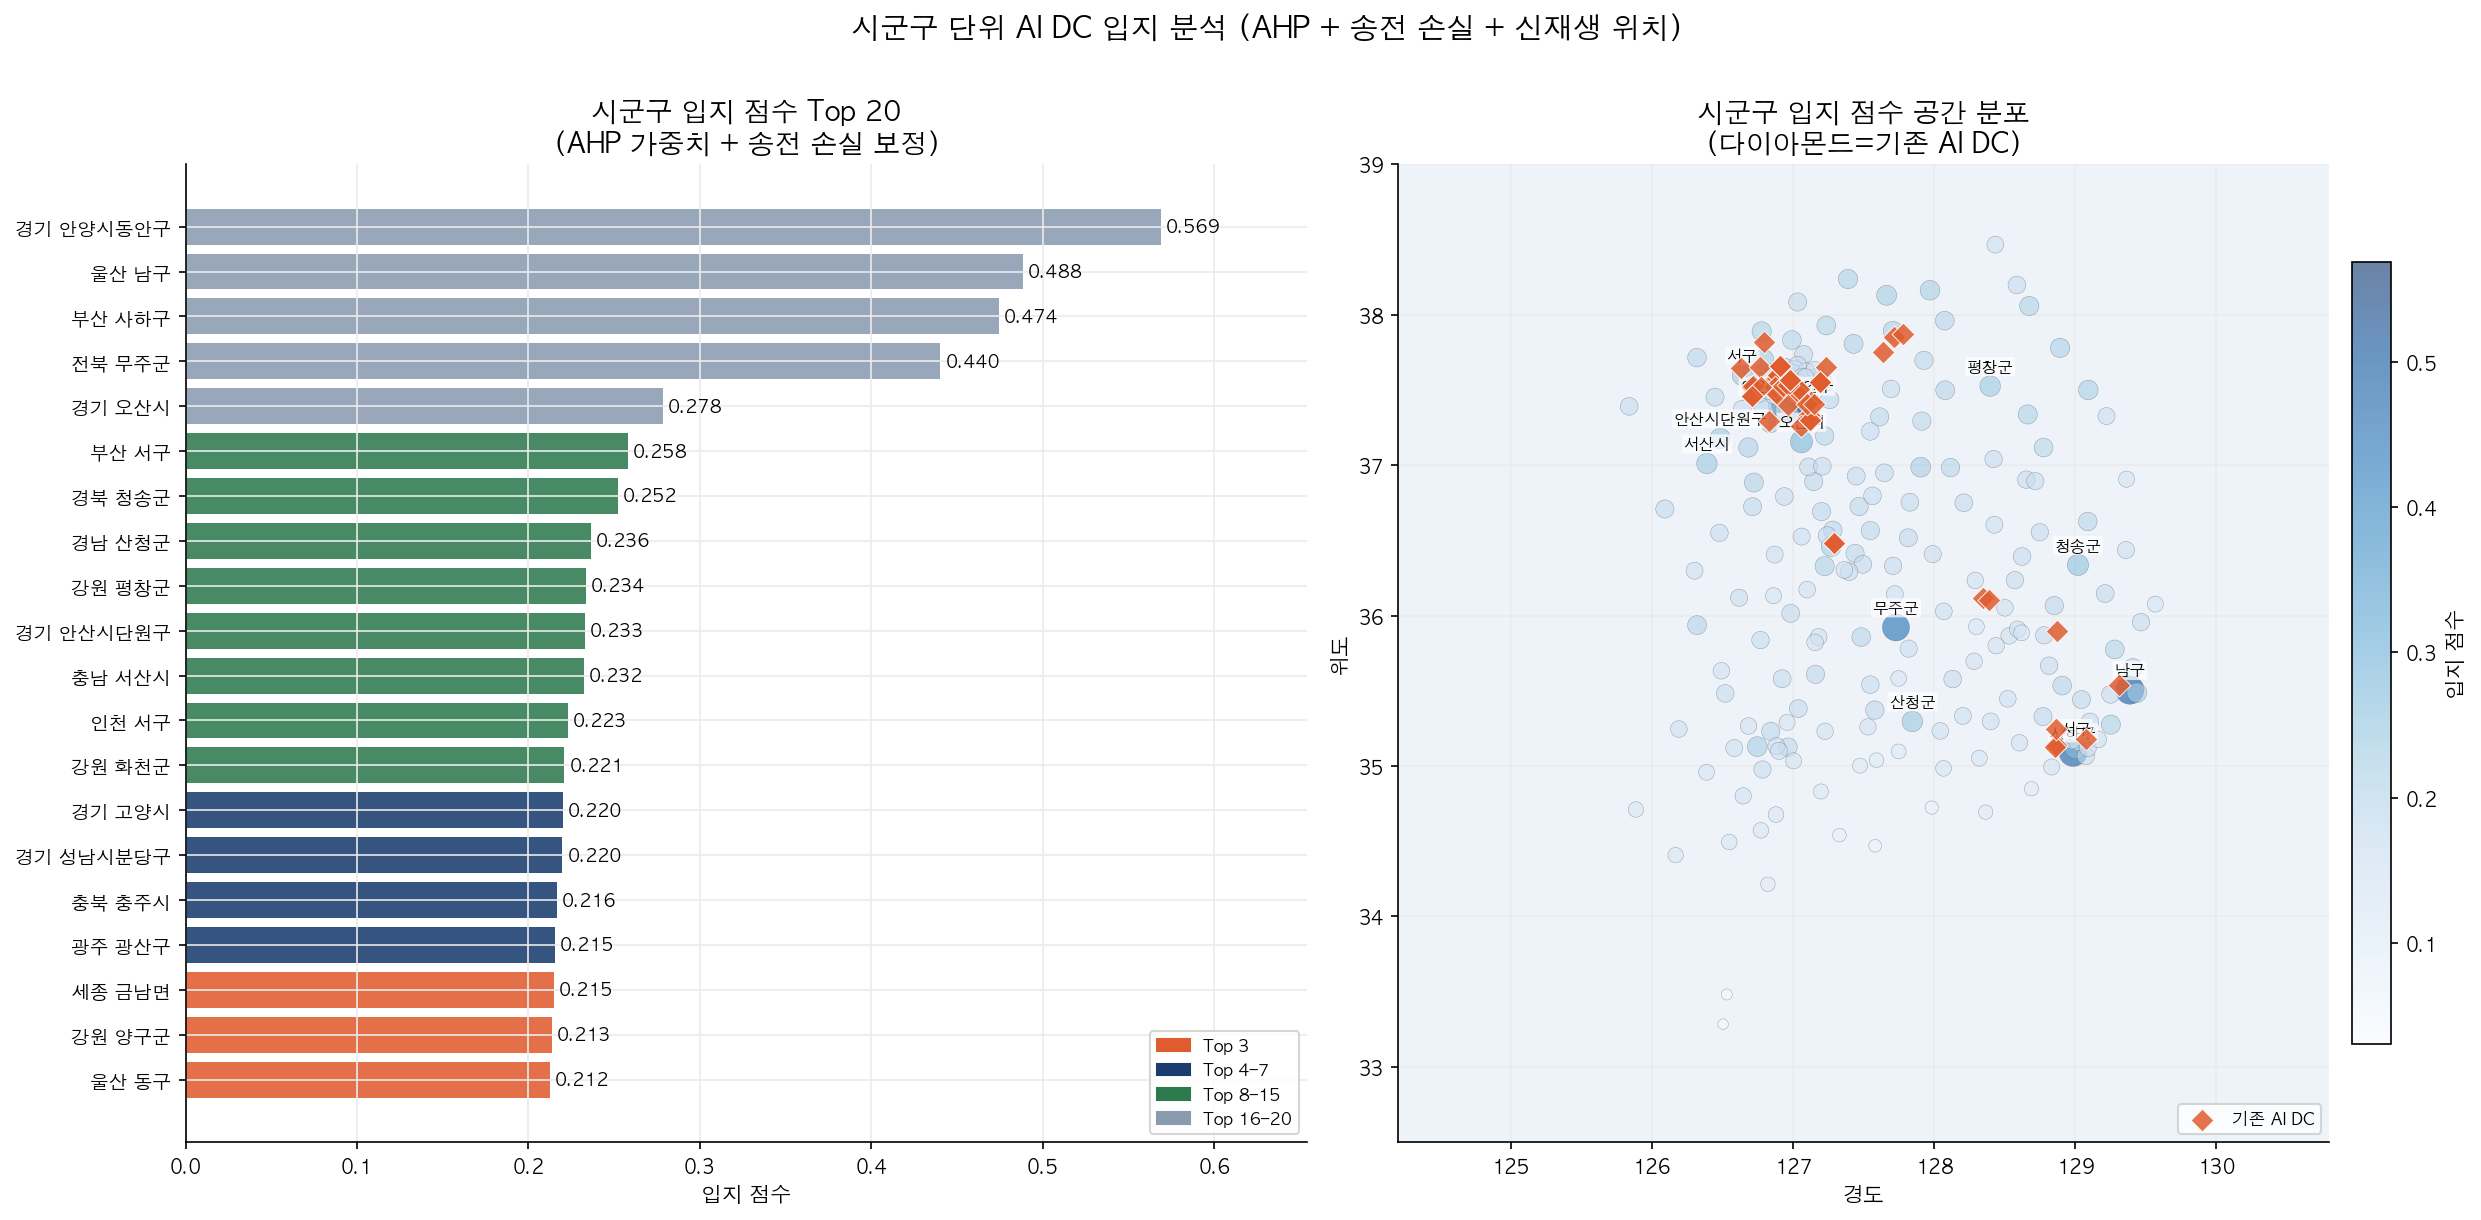

In [ ]:
Image(VIZ + '/03_시군구_입지점수.png')

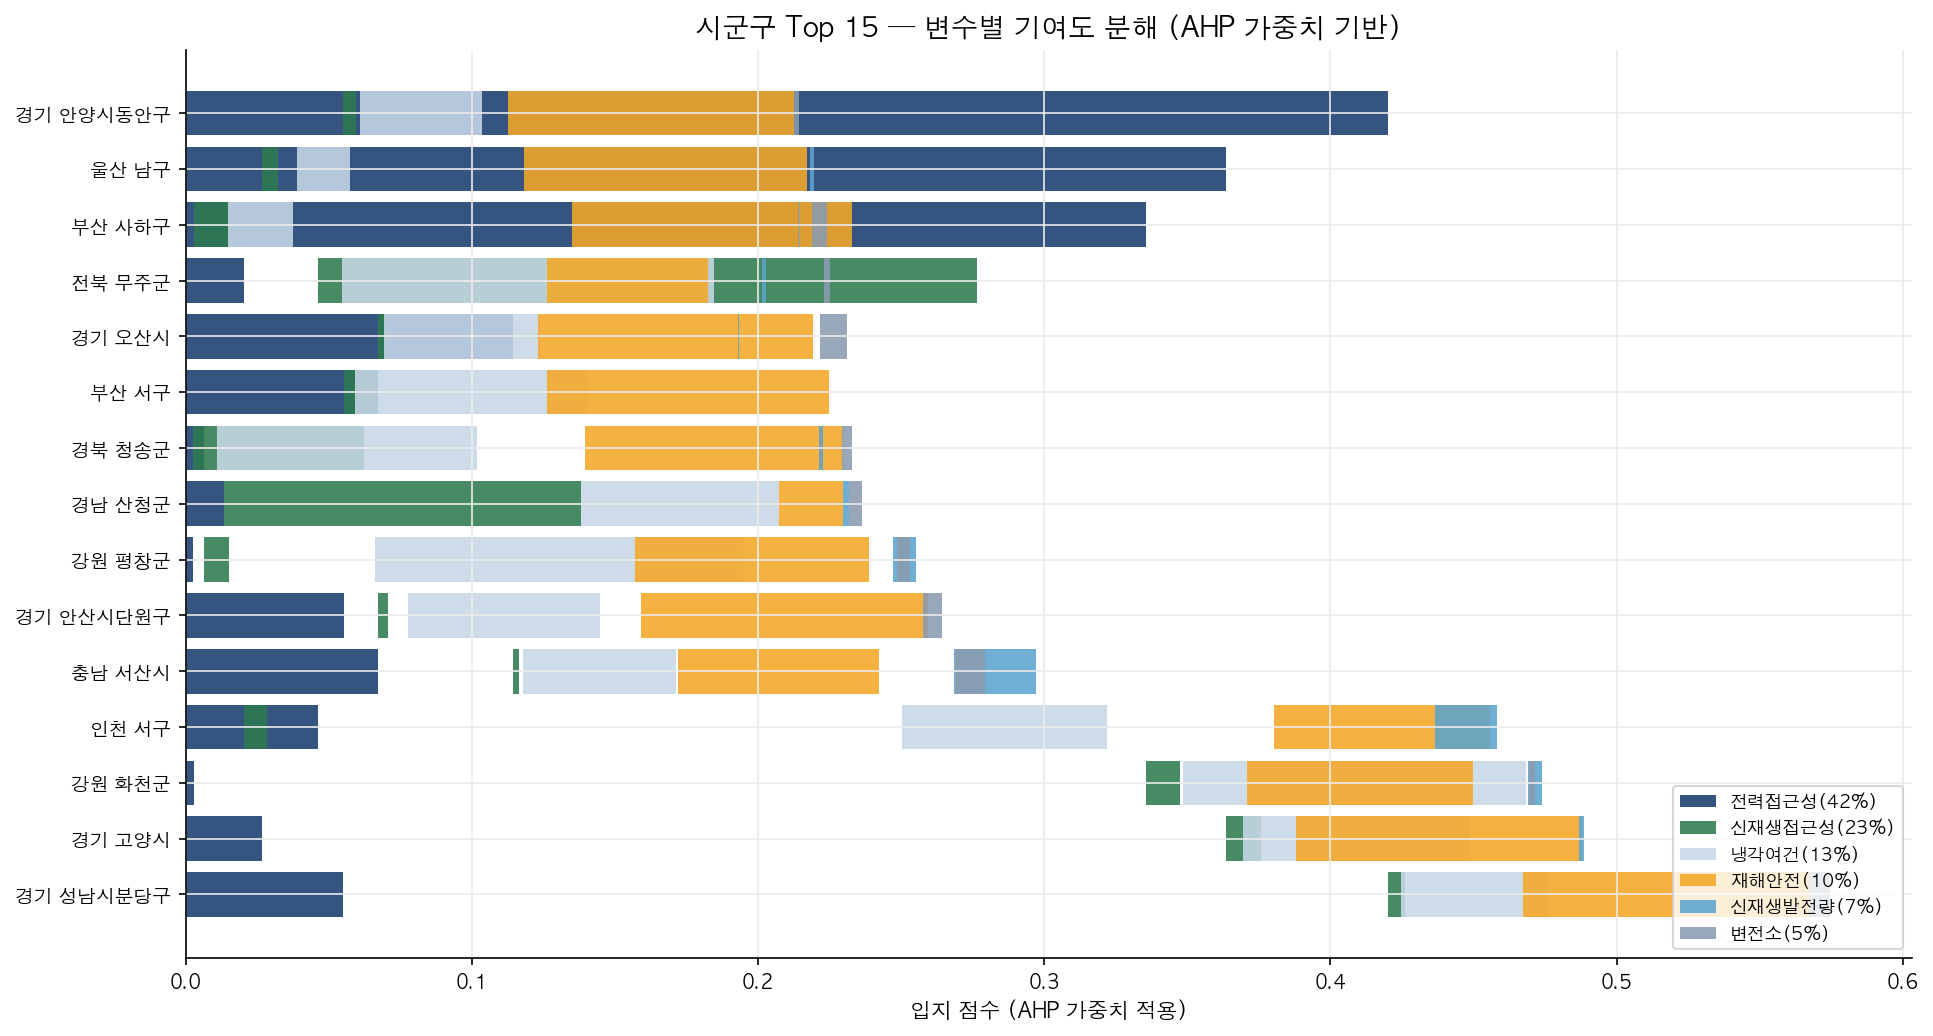

In [ ]:
Image(VIZ + '/04_시군구_변수기여도.png')

## 6. AI DC별 미래 전력 수요 예측

### 추정 근거 (2025년 기준)
| 항목 | 수치 |
|------|------|
| ChatGPT 일일 쿼리 | 1억 건 (OpenAI 2023 발표) |
| 쿼리당 전력 | 0.003 kWh (GPT-4 기준) |
| 국내 LLM 사용 비중 | 5.5% 추정 |
| 국내 AI 추론 전력 | **2.2 TWh/yr** |
| AI 학습 전력 (추론의 2배) | **4.5 TWh/yr** |
| AI DC 총 전력 수요 | **6.7 TWh/yr → 765 MW 상시** |

### Tier별 현재 수전용량
- Tier1 AI특화: 평균 150 MW/개소
- Tier2 하이퍼스케일: 평균 50 MW/개소
- CAGR 시나리오: 보수 15% / 기준 25% / 낙관 35%


In [ ]:
demand = pd.read_csv(BASE + '/수요예측_시뮬레이션.csv')
print(demand.to_string(index=False))

연도  수도권_집중_MW  최적분산_MW  기준시나리오_MW  보수시나리오_MW  낙관시나리오_MW
2025      3449.0    3449.0         4900.0         4900.0         4900.0
2026      4311.0    4311.0         6125.0         5635.0         6615.0
2027      5388.0    5388.0         7656.0         6480.0         8931.0
2028      6735.0    6735.0         9570.0         7452.0        12057.0
2029      8419.0    8419.0        11963.0         8570.0        16277.0
2030     10524.0   10524.0        14953.0         9856.0        21974.0


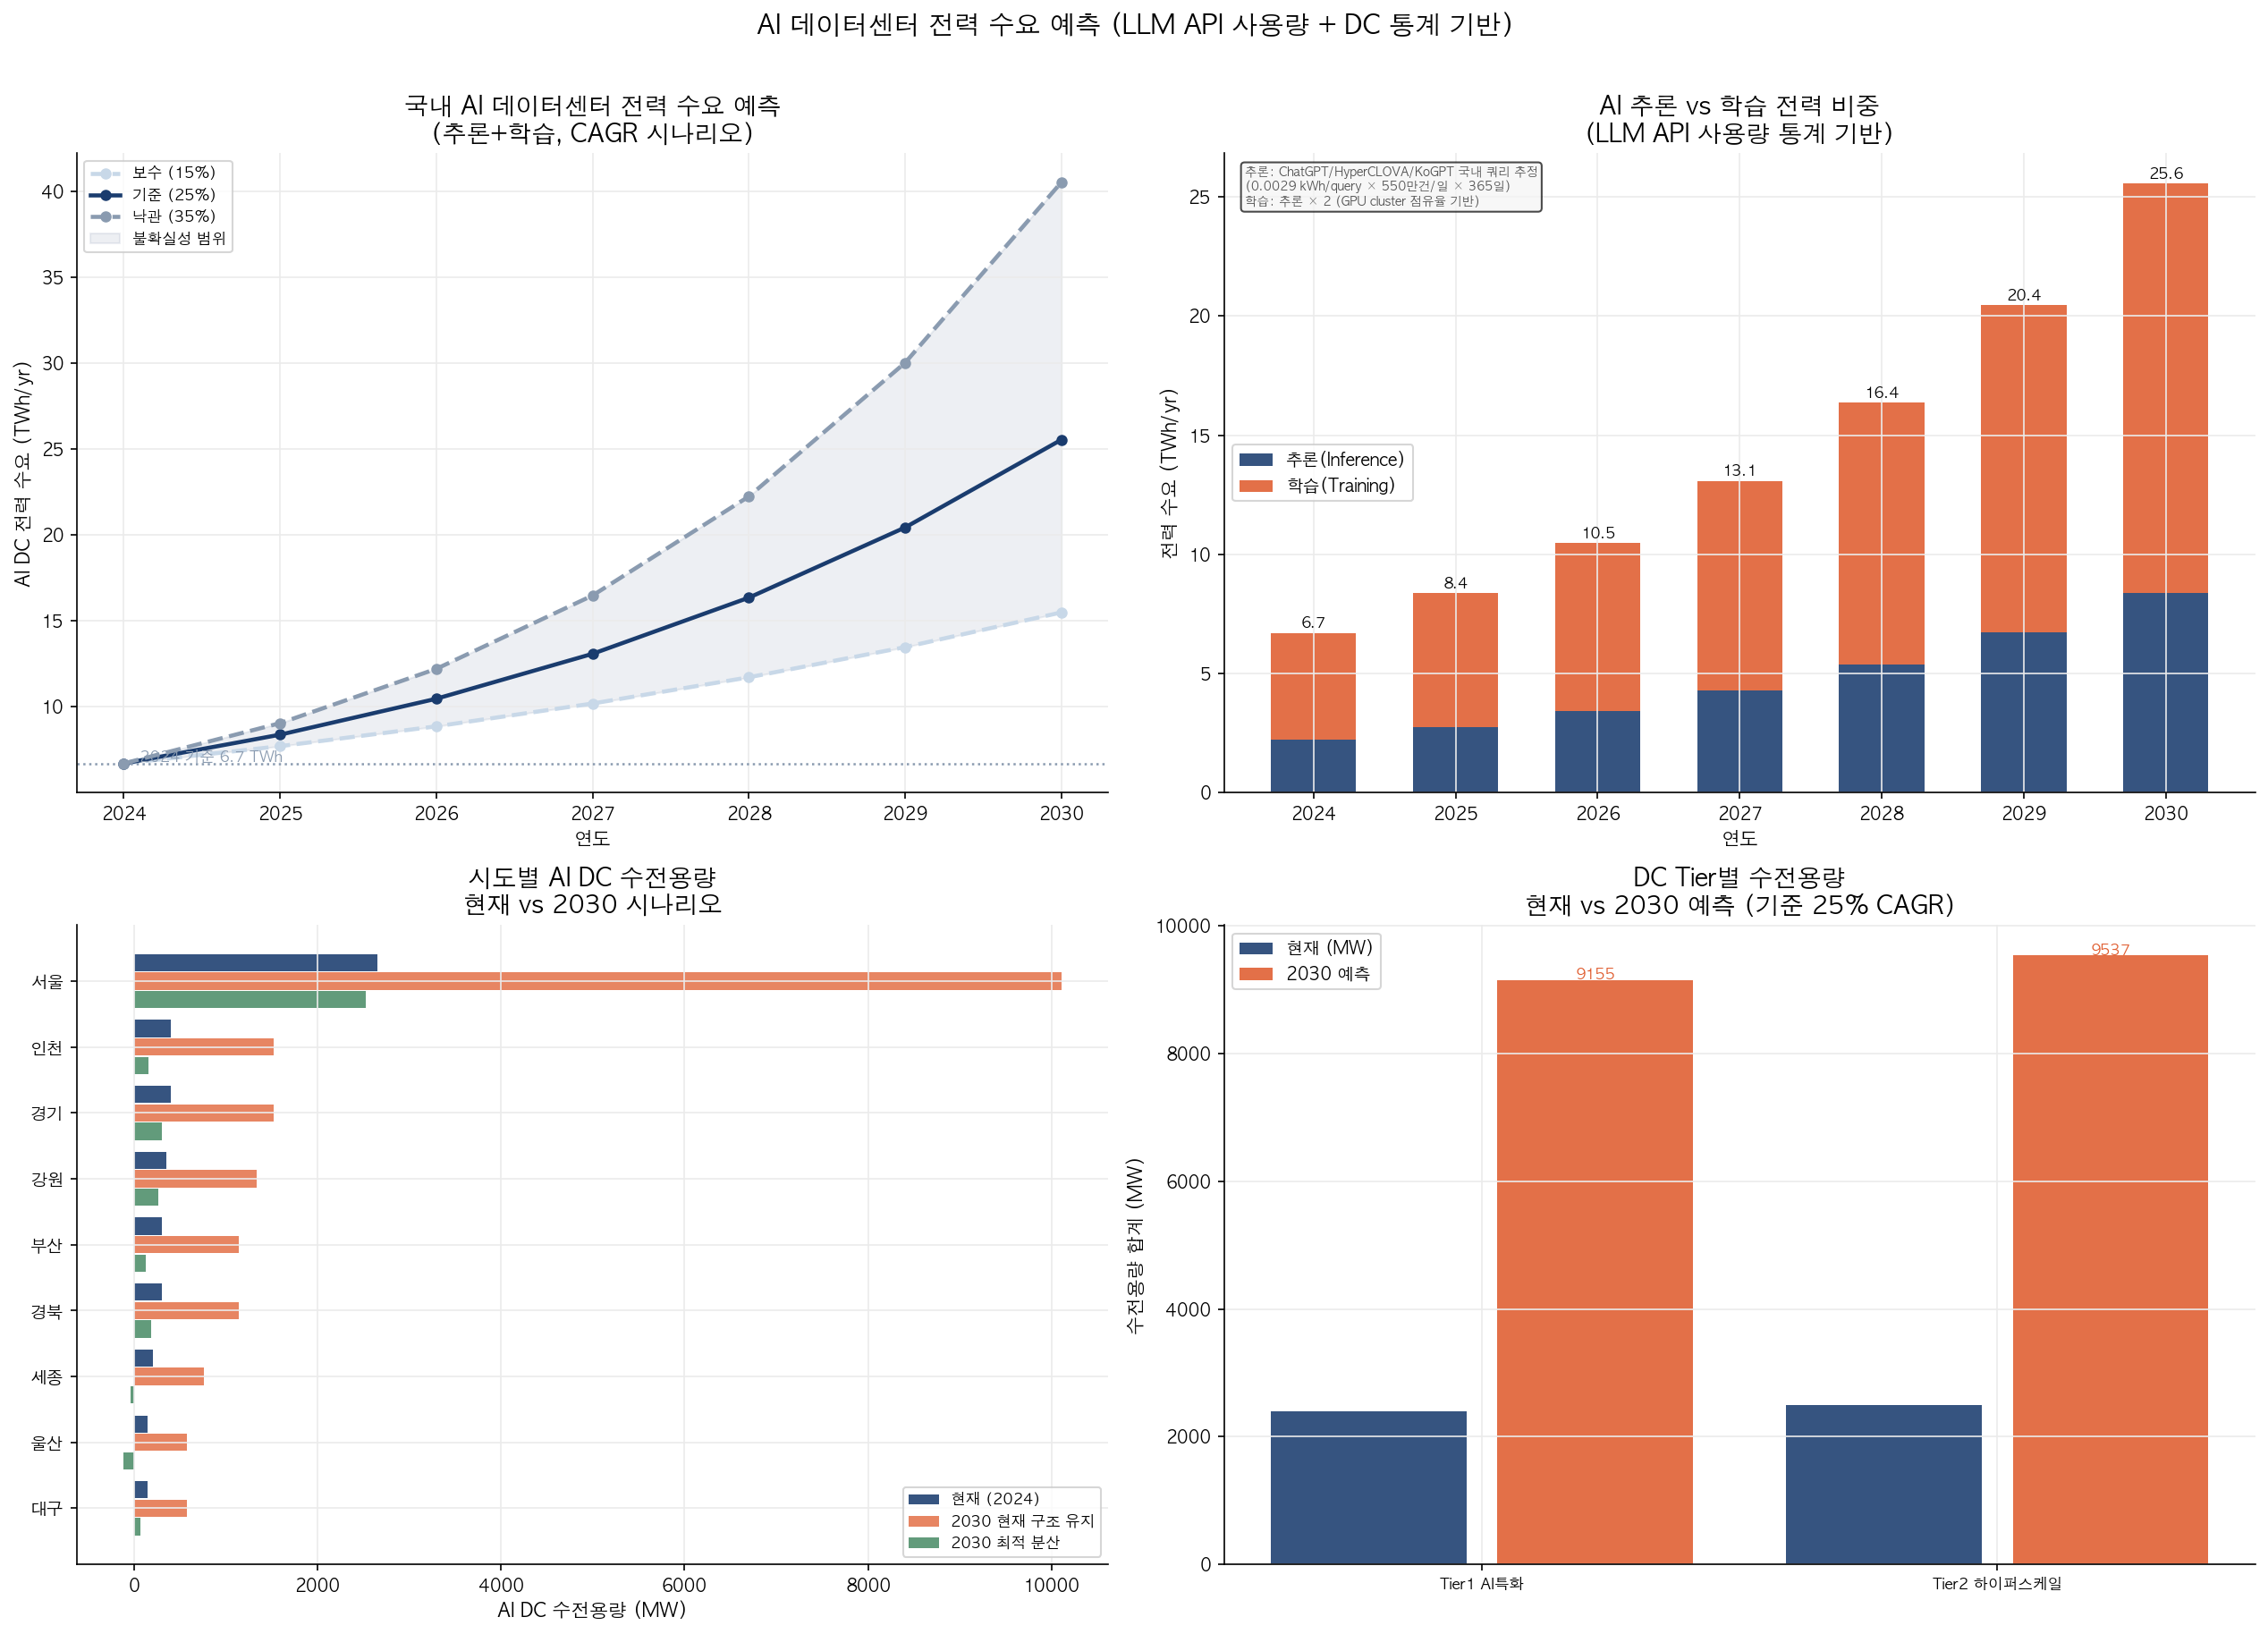

In [ ]:
Image(VIZ + '/05_AI_DC_전력수요예측.png')

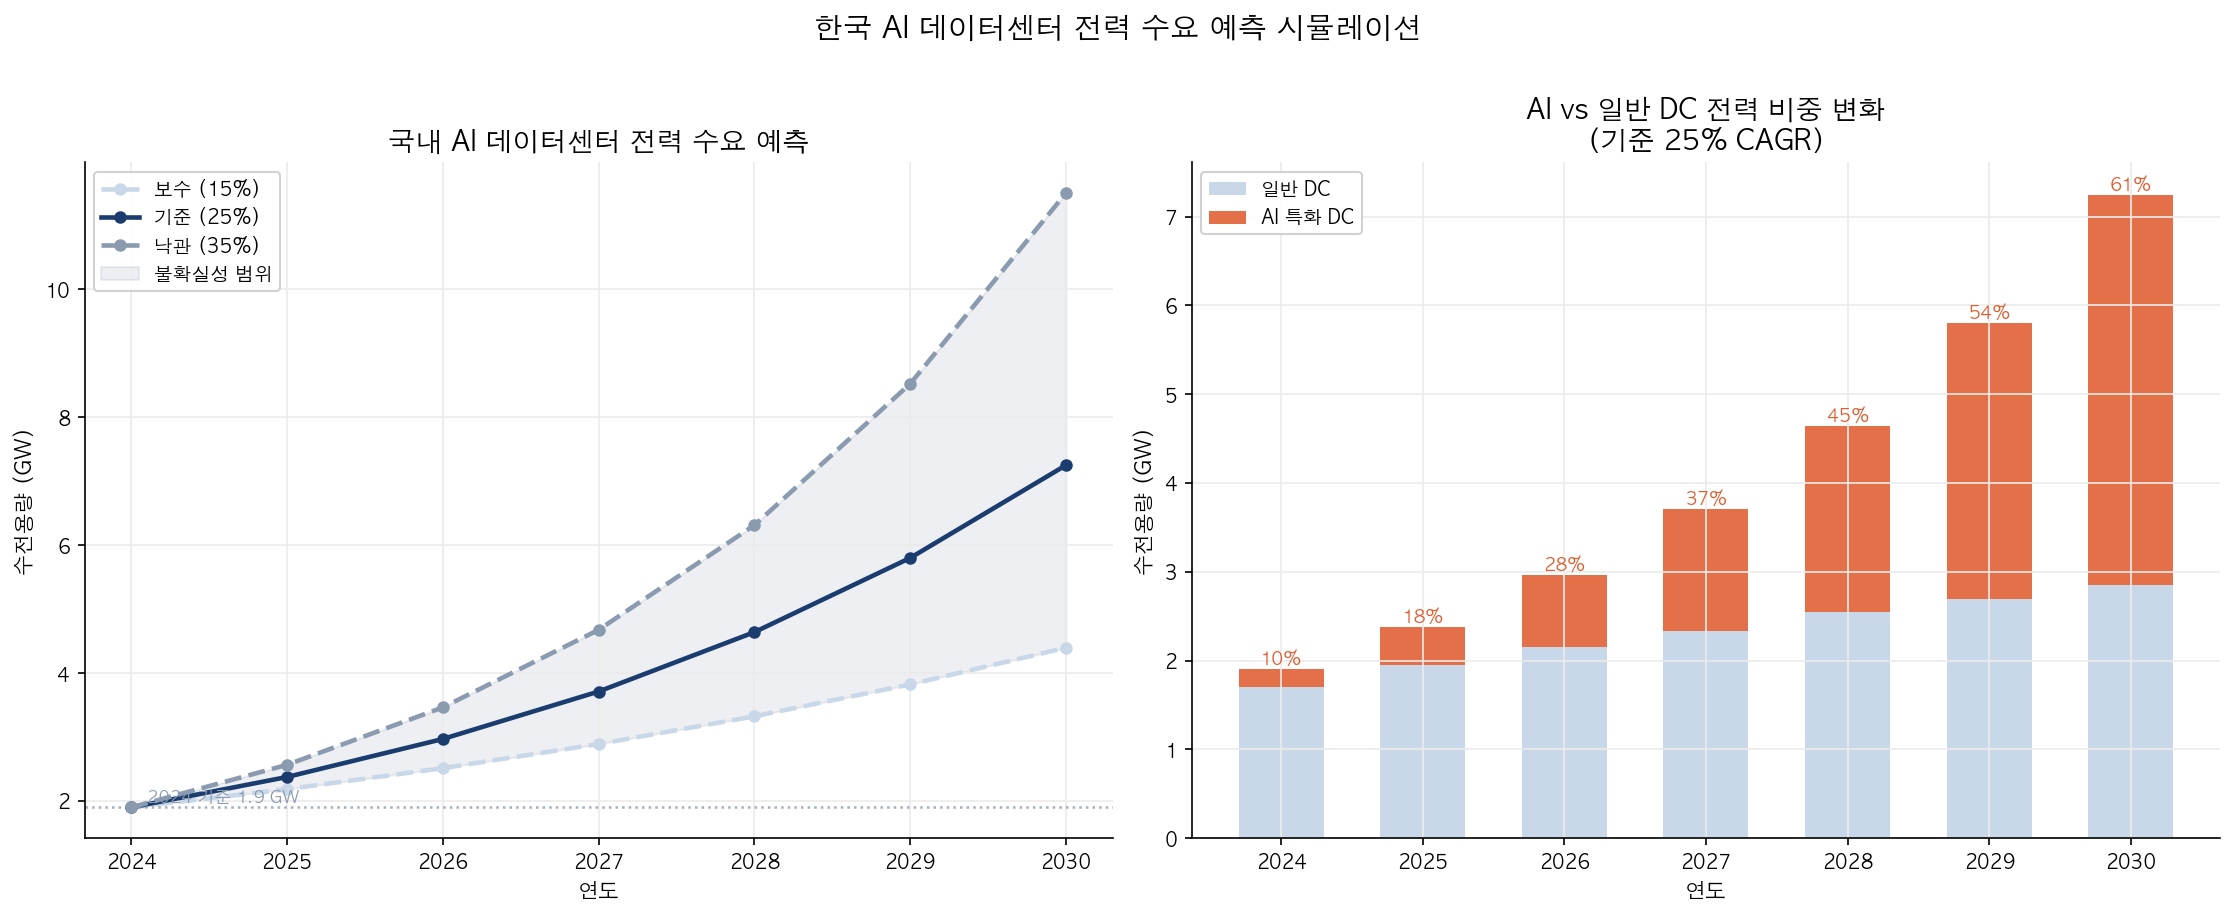

In [ ]:
Image(VIZ + '/05_수요예측_시뮬레이션.png')

## 7. 전력 예비율 시뮬레이션

수도권 집중 vs. 최적 분산 시나리오 비교


In [ ]:
print('=== 2030년 예비율 시뮬레이션 (기준 25% CAGR, 손실 보정) ===
  수도권 집중: 54.3%
  최적 분산  : 54.5%
  분산 배치 이점: +0.12%p
')

=== 2030년 예비율 시뮬레이션 (기준 25% CAGR, 손실 보정) ===
  수도권 집중: 54.3%
  최적 분산  : 54.5%
  분산 배치 이점: +0.12%p


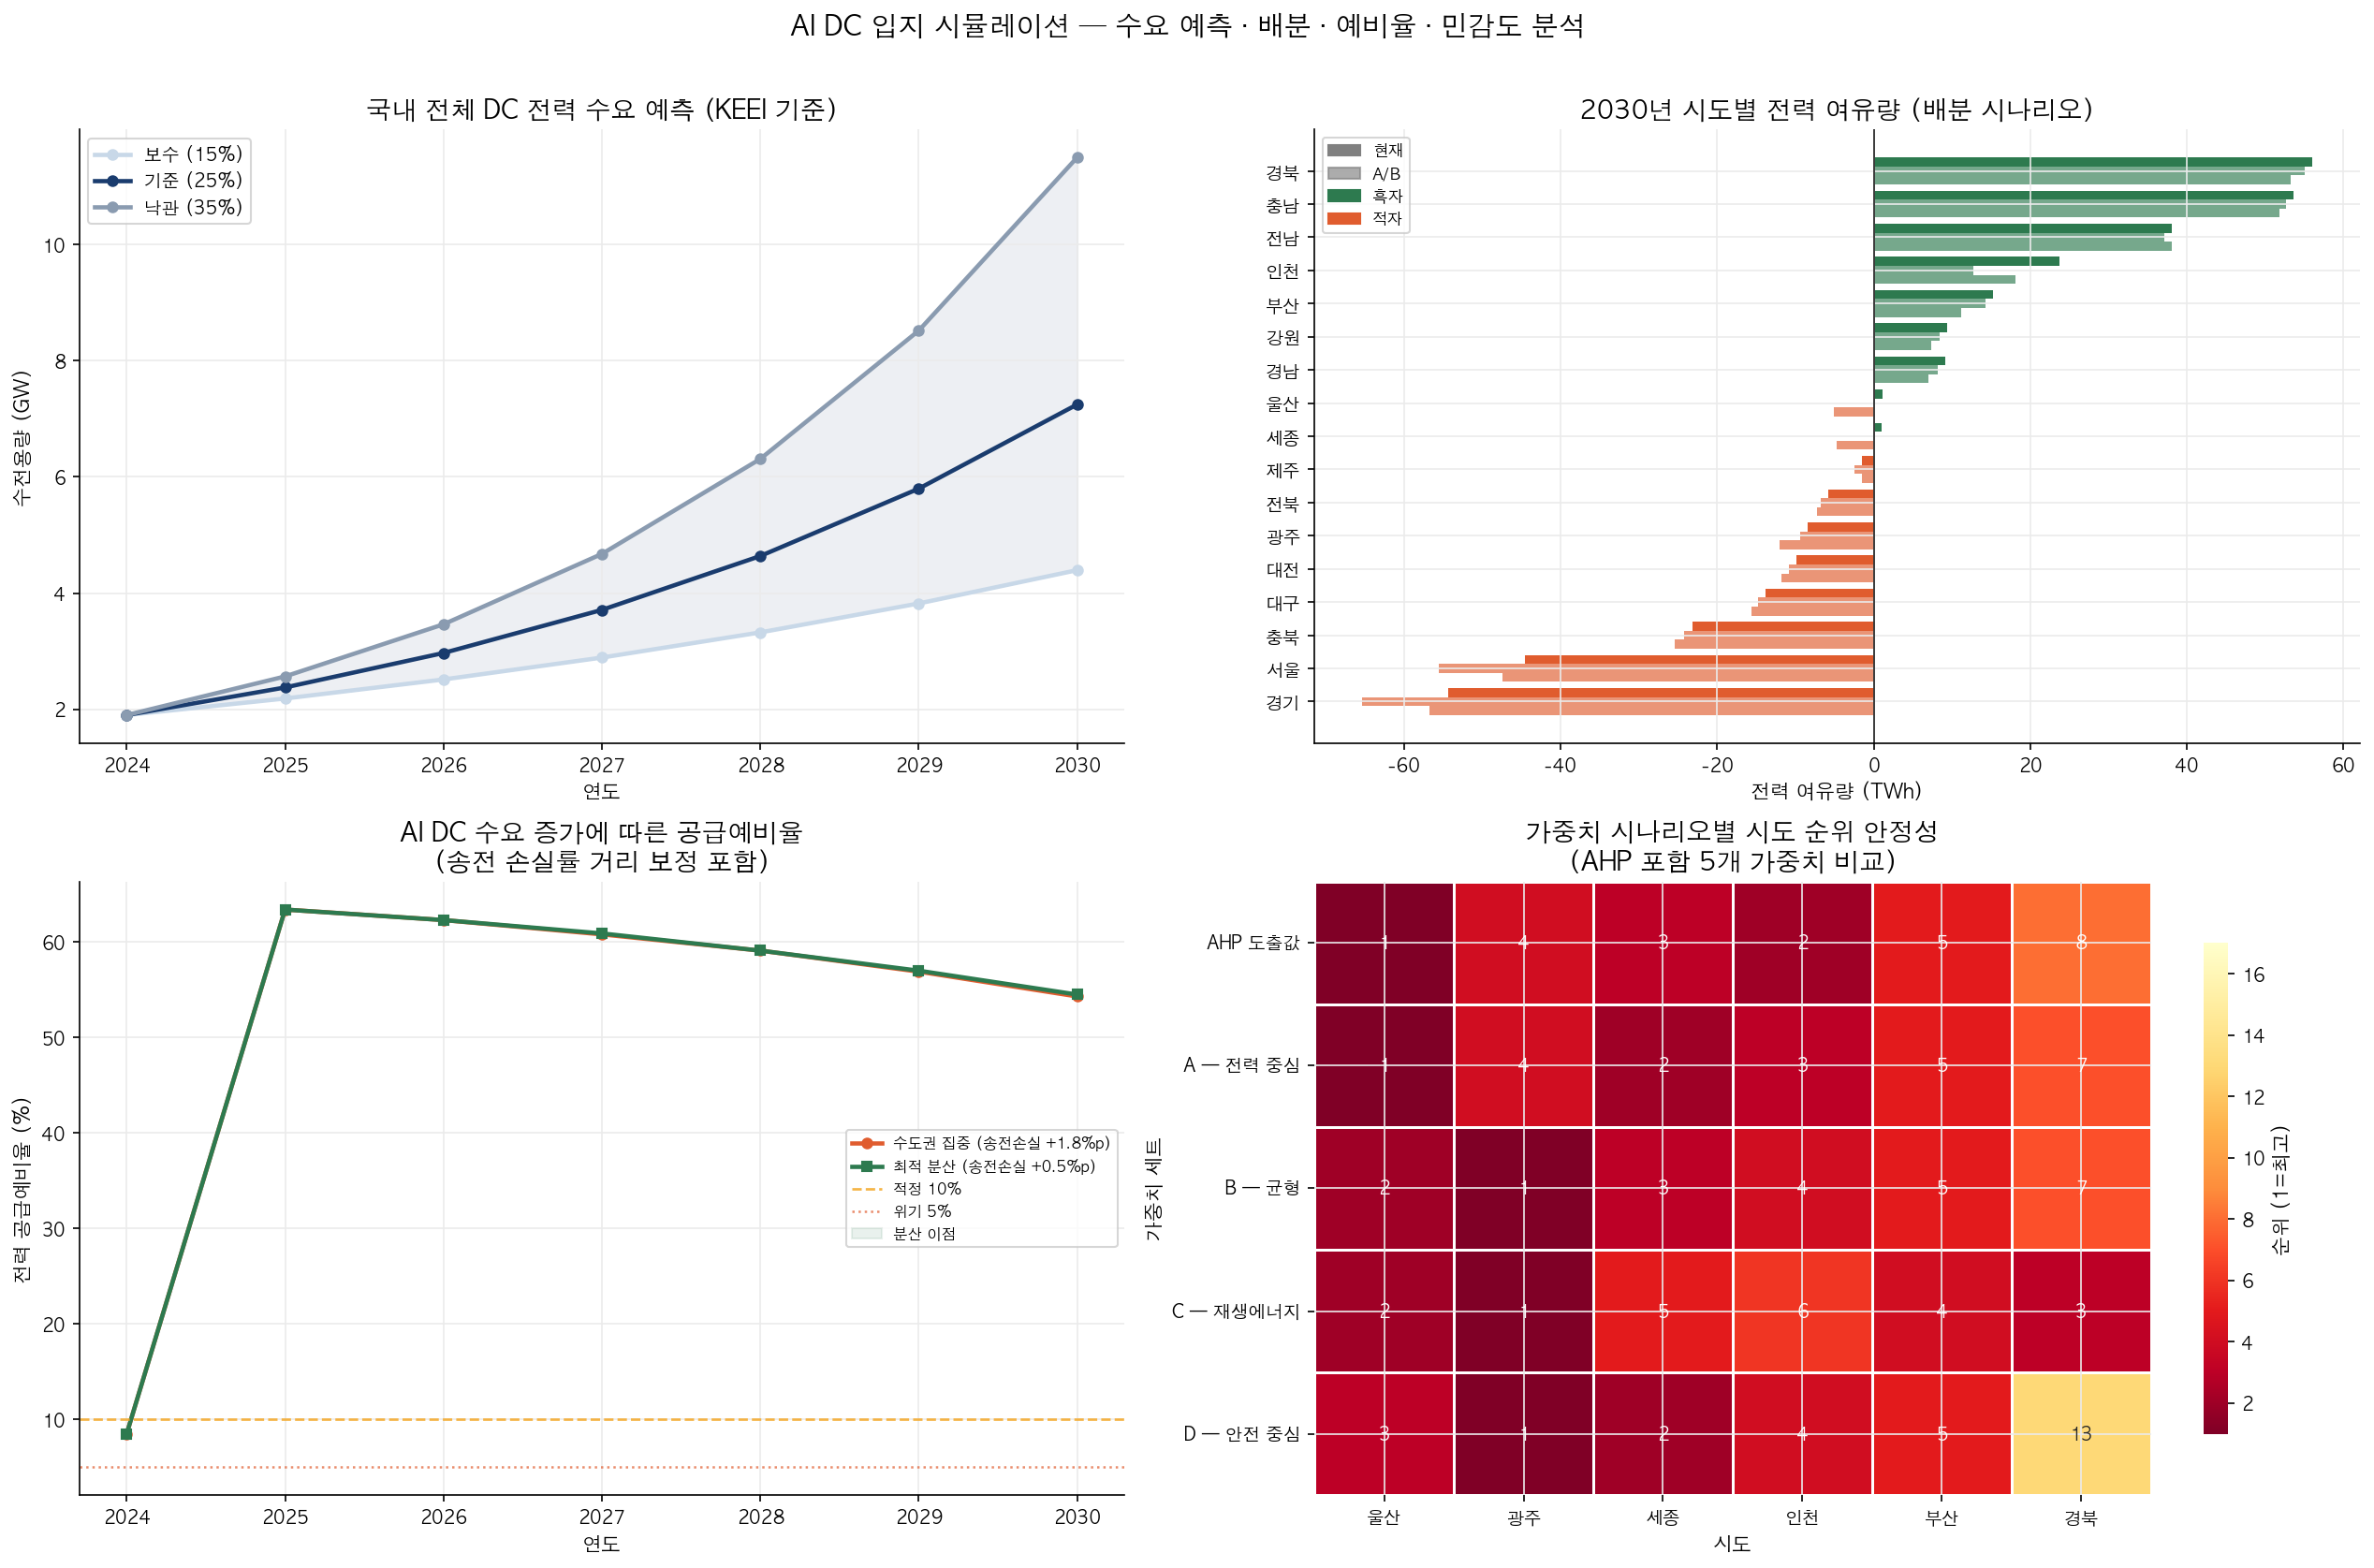

In [ ]:
Image(VIZ + '/06_시뮬레이션_통합.png')

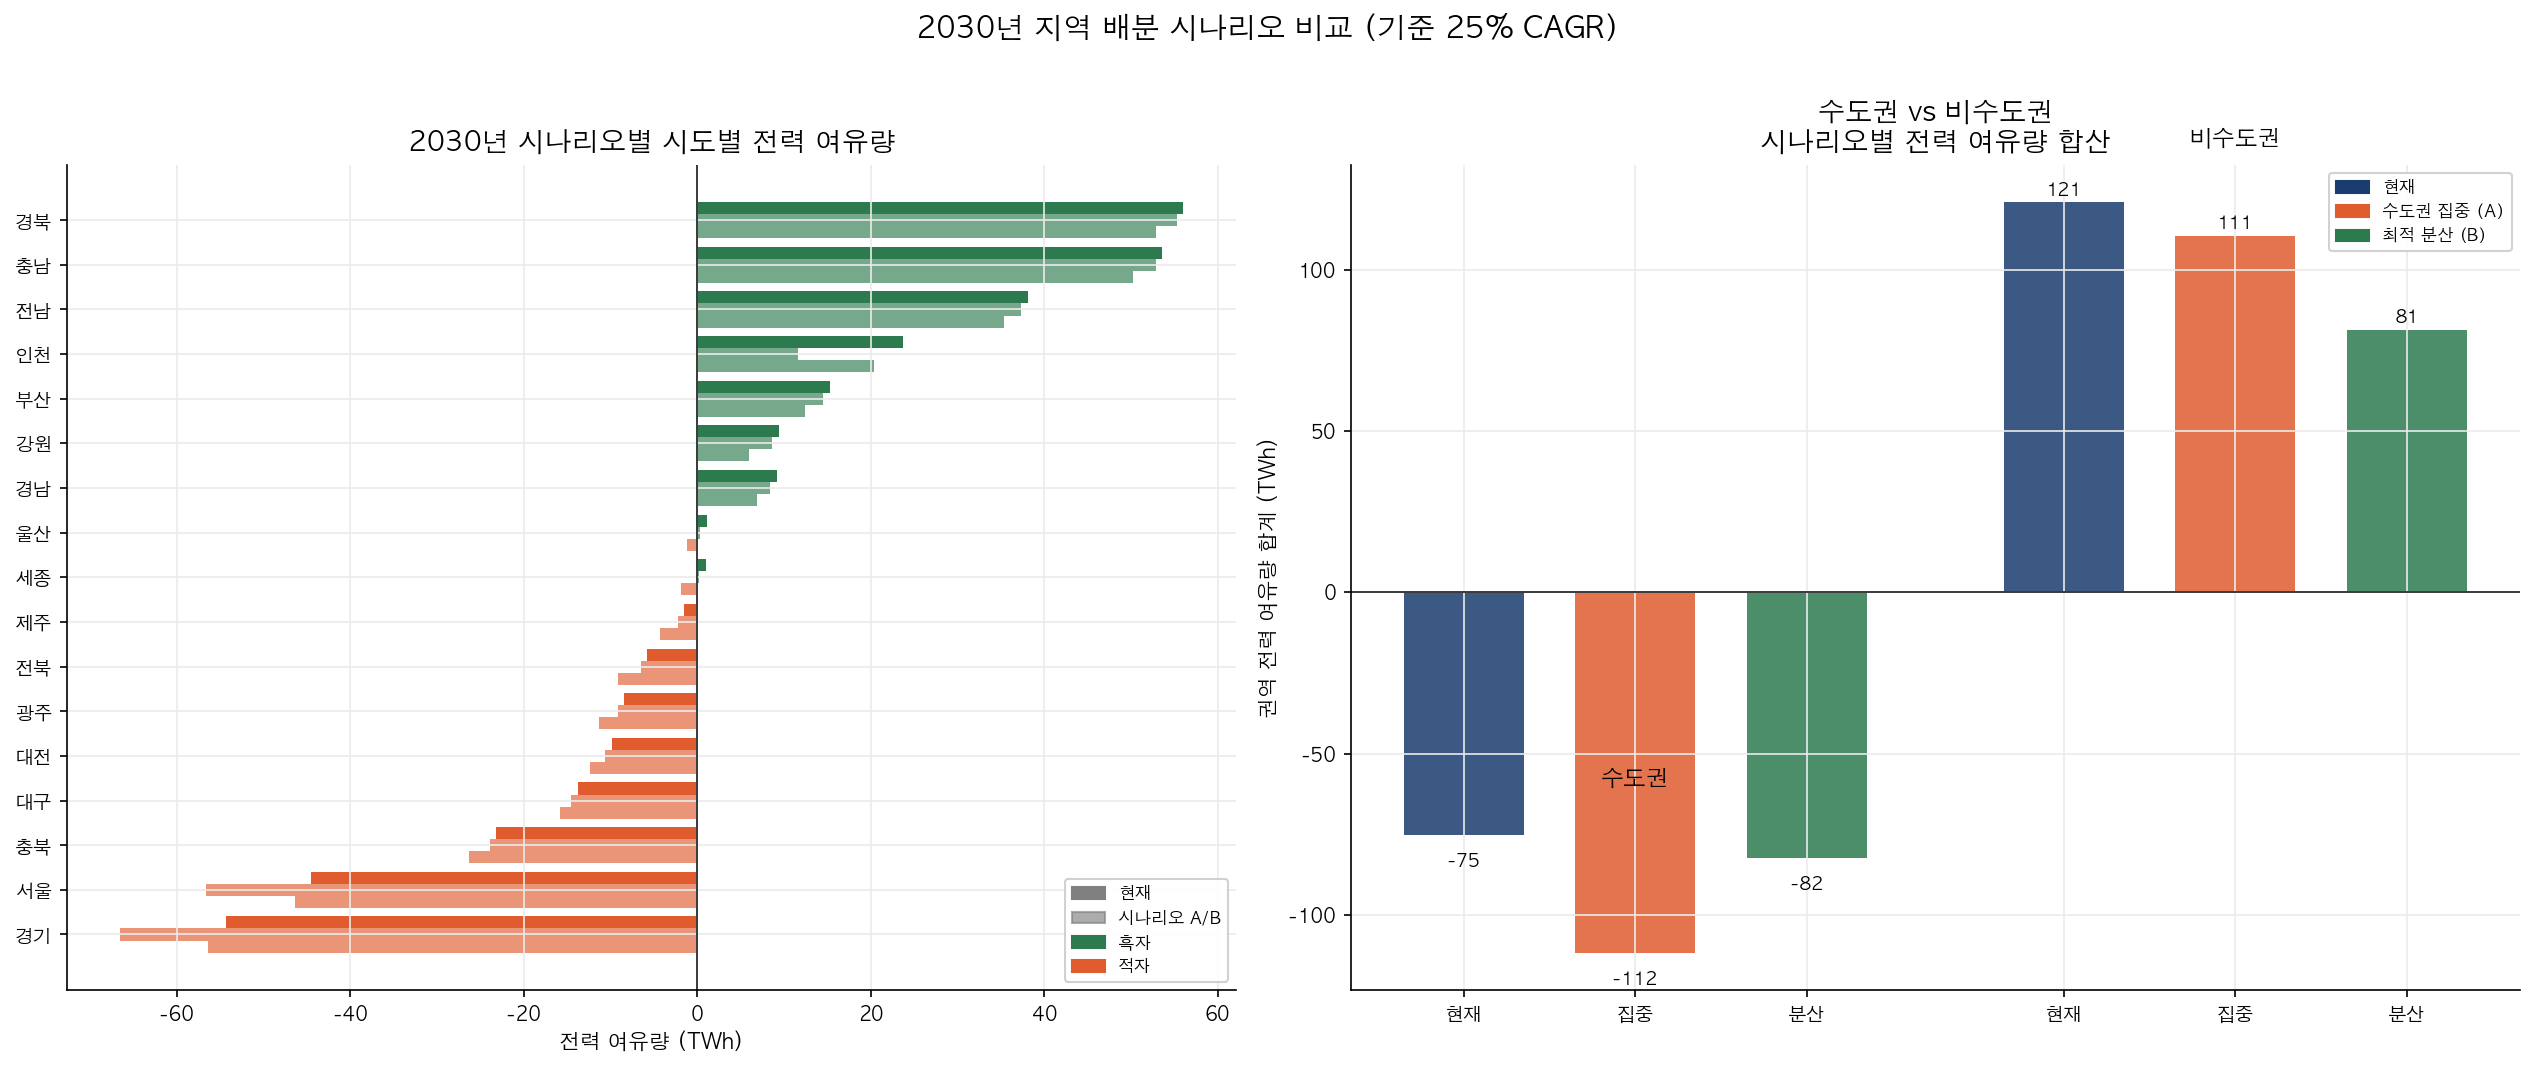

In [ ]:
Image(VIZ + '/06_지역배분_시나리오.png')

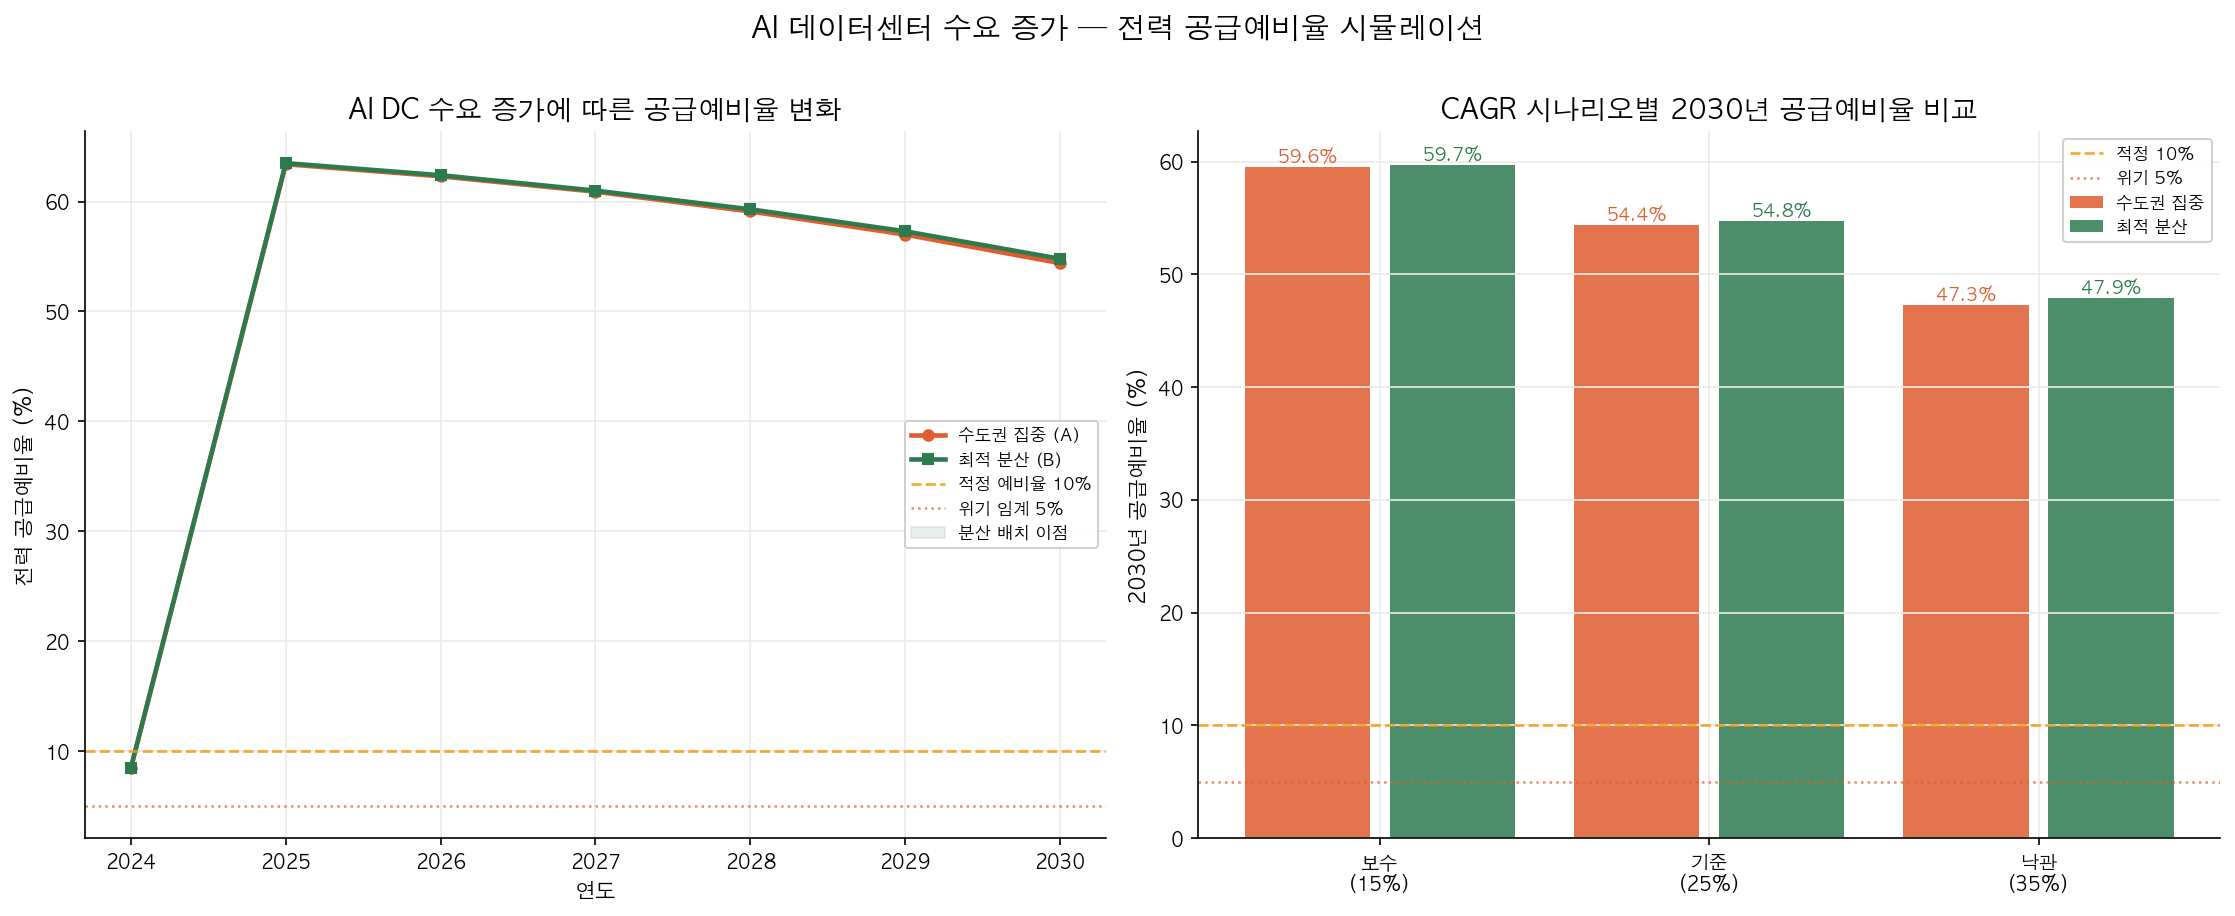

In [ ]:
Image(VIZ + '/07_전력예비율_시뮬레이션.png')

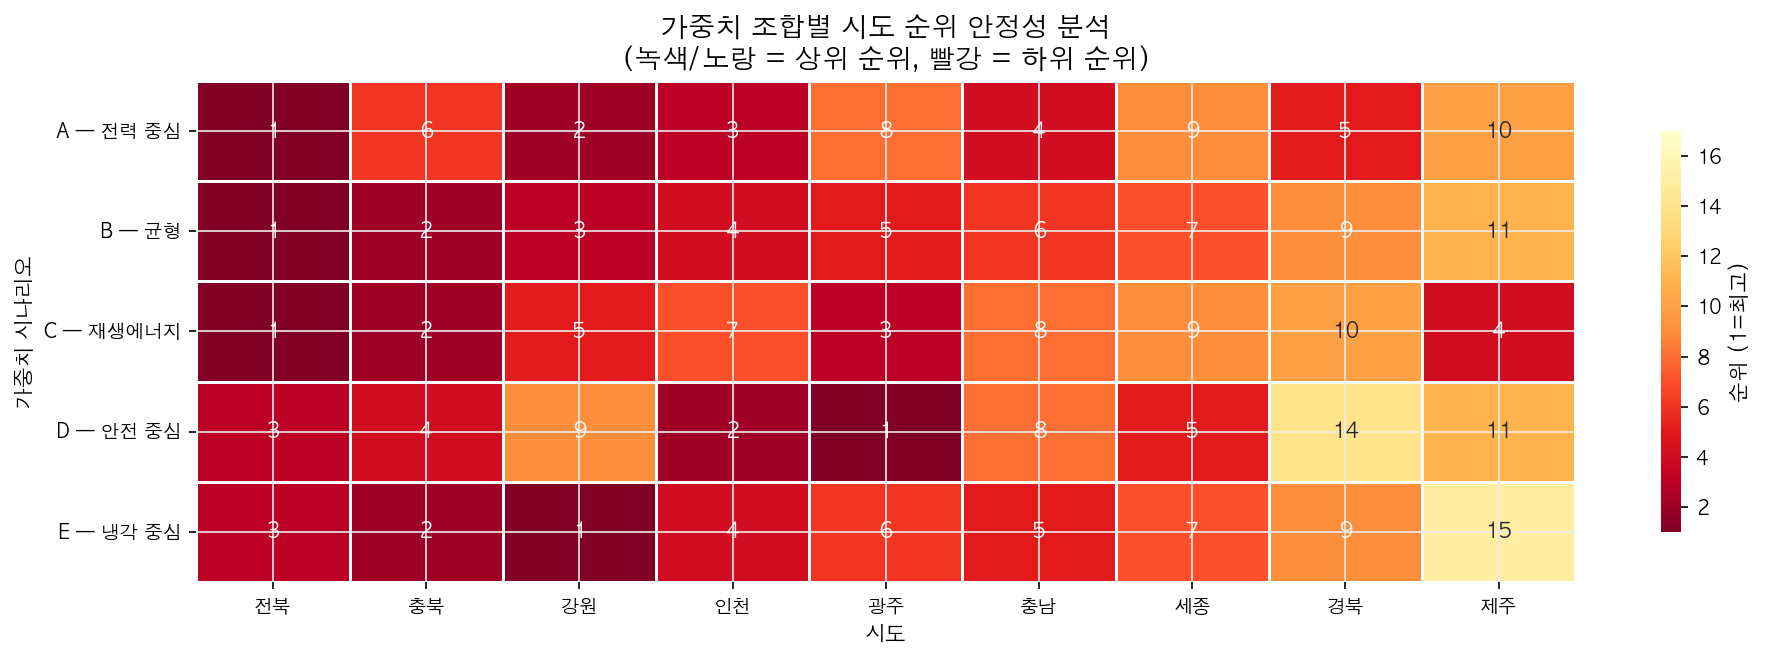

In [ ]:
Image(VIZ + '/08_민감도분석_히트맵.png')

## 8. 종합 결론 및 한계

### 핵심 결과
**시도 Top 3**: 울산 → 인천 → 세종
- 울산: 발전소 밀집(현대제철 등) + 해안 냉각 + 재해 안전
- 인천: 자급률 191% + 항만 물류 + 서울 근접
- 세종: 자급률 124% + 행정 인프라

**시군구 Top 3**: 경기 안양시동안구 → 울산 남구 → 부산 사하구

### 방법론 한계
1. 시군구 좌표: AWS 관측소 평균 (정확한 centroid 미확보)
2. 전력 접근성: 직선거리 기반, 실제 송전망 토폴로지 미반영
3. 태양광 발전소: 17,884개 중 표본 2,000개 활용 (속도 vs 정확도 트레이드오프)
4. AI DC 분류: operator/name 기반 휴리스틱, 실제 워크로드 미확인
5. 전력 수요 예측: LLM API 통계 추정치, 국내 비중 가정 포함
